<a href="https://colab.research.google.com/github/Caio-Oliveira98/Redes-neurais/blob/main/Cp_04_RN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Resolução do Checkpoint - Redes Neurais

# **Objetivo:**
# Este notebook tem como objetivo resolver o Checkpoint utilizando o algoritmo Multi-Layer Perceptron (MLP)
# para regressão, conforme especificado no PDF.

# **Passos:**
# 1. Entendimento do Problema
# 2. Coleta de Dados (com a base de dados 'autos.csv')
# 3. Análise de Dados
# 4. Limpeza dos Dados
# 5. Engenharia de Features
# 6. Modelagem com MLP
# 7. Avaliação do Modelo
# 8. Conclusão

## 1. Entendimento do Problema

# **Objetivo Geral:**
# Criar um modelo de Redes neurais capaz de prever o preço de veículos usados com base em suas características.

##**Por que isso é importante?**
 Prever o preço de um veículo usado é útil para:
 - Compradores: Saber se estão pagando um preço justo.
   *Exemplo:* Um comprador pode usar o modelo para verificar se o preço pedido por um vendedor está de acordo com as características do veículo (ano, modelo, quilometragem, etc.).
 - Vendedores: Definir um preço competitivo para vender mais rápido.
   *Exemplo:* Um vendedor pode usar o modelo para definir um preço que atraia compradores,mas que também garanta um bom retorno financeiro.
 - Empresas: Avaliar o valor de seus ativos (frota de veículos, etc.).
   *Exemplo:* Uma empresa de aluguel de carros pode usar o modelo para estimar o valor de sua frota de veículos usados para fins de contabilidade ou venda.

# **Algoritmo:**
 Utilizaremos o Multi-Layer Perceptron (MLP), um modelo de rede neural que pode capturar padrões complexos nos dados para fazer previsões de regressão precisas. O MLP é composto por várias camadas de neurônios interconectados, permitindo que o modelo aprenda relações não lineares entre as variáveis.

# **Dataset:**
 O dataset a ser utilizado é o 'autos.csv', que contém informações sobre veículos usados
 (marca, modelo, ano, quilometragem, etc.).

# **Variáveis:**
# As variáveis disponíveis no dataset são:
 1. DateCrawled: data rastreada (data em que o anúncio foi coletado)
 2. Name: nome do anúncio
 3. seller: tipo de vendedor (privado ou comercial)
 4. offerType: tipo de oferta (leilão, venda direta, etc.)
 5. Price (target): preço do veículo (o que queremos prever)
 6. abtest: se o anúncio participou de um teste A/B
 7. vehicleType: tipo de veículo (carro, moto, caminhão, etc.)
 8. yearOfRegistration: ano de registro do veículo
 9. gearbox: tipo de câmbio (manual ou automático)
 10. powerPS: potência do motor em cavalos (PS)
 11. model: modelo do veículo
 12. kilometer: quilometragem percorrida
 13. monthOfRegistration: mês de registro do veículo
 14. fuelType: tipo de combustível
 15. brand: marca do veículo
 16. notRepairedDamage: se o veículo possui danos não reparados
 17. dateCreated: data de criação do anúncio
 18. nrOfPictures: número de fotos no anúncio
 19. postalCode: código postal do anunciante
 20. lastSeen: data da última vez em que o anúncio foi visto

# **Métrica de Avaliação:**
 Mean Absolute Error (MAE): Mede a diferença média absoluta entre os valores previstos pelo
 modelo e os valores reais. Quanto menor o MAE, melhor o modelo. O MAE é uma métrica fácil de
 interpretar e é útil para entender a magnitude dos erros do modelo.


## 2. Coleta de Dados

# **Objetivo:**
 Importar as bibliotecas necessárias e carregar o dataset 'autos.csv' para análise.

# **Bibliotecas:**
 - pandas: Para manipulação e análise de dados tabulares (como tabelas). Permite ler,
  manipular e transformar dados de forma eficiente.
 - numpy: Para operações numéricas eficientes (cálculos matemáticos). O numpy é otimizado para
   realizar cálculos em arrays e matrizes de forma rápida.
 - matplotlib.pyplot: Para criação de gráficos e visualizações. Permite criar gráficos de linha,
   barras, histogramas, etc.
 - seaborn: Para criação de gráficos estatísticos mais atraentes. O seaborn é construído sobre o
   matplotlib e oferece uma interface mais amigável para criar gráficos estatísticos.
 - sklearn.model_selection: Para dividir os dados em conjuntos de treinamento e teste. É fundamental
   dividir os dados para avaliar o desempenho do modelo em dados não vistos.
 - sklearn.preprocessing: Para pré-processar os dados (transformar variáveis, etc.). O pré-processamento
   é uma etapa importante para garantir que os dados estejam em um formato adequado para o modelo.
 - sklearn.impute: Para lidar com valores ausentes nos dados. Valores ausentes podem prejudicar o
   desempenho do modelo, por isso é importante tratá-los.
 - sklearn.neural_network: Para utilizar o modelo MLP para regressão. O MLP é um modelo de rede
   neural que pode ser usado para problemas de regressão e classificação.
 - sklearn.metrics: Para calcular métricas de avaliação do modelo (como o MAE). As métricas de
   avaliação são usadas para medir o desempenho do modelo.
 - datetime: Para trabalhar com datas e horários. Permite realizar operações com datas, como
   calcular a idade de um veículo.


In [1]:
# Importação das bibliotecas
import pandas as pd  # Manipulação e análise de dados tabulares
import numpy as np  # Operações numéricas
import matplotlib.pyplot as plt  # Criação de gráficos e visualizações
import seaborn as sns  # Criação de gráficos estatísticos mais atraentes
from sklearn.model_selection import train_test_split  # Divisão dos dados
from sklearn.preprocessing import StandardScaler, OneHotEncoder  # Pré-processamento dos dados
from sklearn.impute import SimpleImputer # Imputação de valores ausentes
from sklearn.pipeline import Pipeline  # Criação de pipeline para o pré-processamento
from sklearn.compose import ColumnTransformer  # Transformação em combinação de colunas
from sklearn.neural_network import MLPRegressor  # Modelo MLP para regressão
from sklearn.metrics import mean_absolute_error  # Métrica de avaliação do modelo
import datetime  # Manipulação de datas
from datetime import datetime  # Manipulação de datas

# Carregando o dataset 'autos.csv'

In [2]:
# Explicação:
# - pd.read_csv(): Função do pandas para ler arquivos CSV (arquivos de tabela).
# - encoding='ISO-8859-1': Especifica a codificação dos caracteres do arquivo. Isso é importante
#   para garantir que caracteres especiais (como letras acentuadas) sejam lidos corretamente.
df = pd.read_csv('autos.csv', encoding='ISO-8859-1')

In [3]:
# Exibindo as primeiras linhas do dataset para verificar se o carregamento foi bem-sucedido
# Explicação:
# - df.head(): Função do pandas para exibir as primeiras linhas do DataFrame (tabela).
#   Por padrão, exibe as 5 primeiras linhas.
print("\nVisualizando as primeiras linhas do dataset:")
print(df.head())


Visualizando as primeiras linhas do dataset:
           dateCrawled                            name  seller offerType  \
0  2016-03-24 11:52:17                      Golf_3_1.6  privat   Angebot   
1  2016-03-24 10:58:45            A5_Sportback_2.7_Tdi  privat   Angebot   
2  2016-03-14 12:52:21  Jeep_Grand_Cherokee_"Overland"  privat   Angebot   
3  2016-03-17 16:54:04              GOLF_4_1_4__3TÜRER  privat   Angebot   
4  2016-03-31 17:25:20  Skoda_Fabia_1.4_TDI_PD_Classic  privat   Angebot   

   price abtest vehicleType  yearOfRegistration    gearbox  powerPS  model  \
0    480   test         NaN                1993    manuell        0   golf   
1  18300   test       coupe                2011    manuell      190    NaN   
2   9800   test         suv                2004  automatik      163  grand   
3   1500   test  kleinwagen                2001    manuell       75   golf   
4   3600   test  kleinwagen                2008    manuell       69  fabia   

   kilometer  monthOfRegistr

## 3. Análise de Dados

 **Objetivo:**
 Realizar uma análise exploratória dos dados para entender melhor as relações entre as
 variáveis, tratar valores ausentes e remover colunas desnecessárias para preparar o dataset
 para a modelagem.

# **Análise Exploratória:**
 - Verificar os tipos de dados de cada coluna.
 - Calcular estatísticas descritivas (média, mediana, desvio padrão, etc.).
 - Identificar valores ausentes.
 - Visualizar a distribuição das variáveis.

In [4]:
# - Utilizando a função `df.info()` para obter informações sobre os tipos de dados e valores ausentes.
# Informações iniciais do dataset
print("\nInformações gerais do dataset:")
print(df.info())


Informações gerais do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 371528 entries, 0 to 371527
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   dateCrawled          371528 non-null  object
 1   name                 371528 non-null  object
 2   seller               371528 non-null  object
 3   offerType            371528 non-null  object
 4   price                371528 non-null  int64 
 5   abtest               371528 non-null  object
 6   vehicleType          333659 non-null  object
 7   yearOfRegistration   371528 non-null  int64 
 8   gearbox              351319 non-null  object
 9   powerPS              371528 non-null  int64 
 10  model                351044 non-null  object
 11  kilometer            371528 non-null  int64 
 12  monthOfRegistration  371528 non-null  int64 
 13  fuelType             338142 non-null  object
 14  brand                371528 non-null  object
 15  no

In [5]:
# - Utilizando a função `df.describe()` para obter estatísticas descritivas das variáveis numéricas.
# Estatísticas descritivas
print("\nEstatísticas descritivas:")
print(df.describe(include='all'))


Estatísticas descritivas:
                dateCrawled         name  seller offerType         price  \
count                371528       371528  371528    371528  3.715280e+05   
unique               280500       233531       2         2           NaN   
top     2016-03-24 14:49:47  Ford_Fiesta  privat   Angebot           NaN   
freq                      7          657  371525    371516           NaN   
mean                    NaN          NaN     NaN       NaN  1.729514e+04   
std                     NaN          NaN     NaN       NaN  3.587954e+06   
min                     NaN          NaN     NaN       NaN  0.000000e+00   
25%                     NaN          NaN     NaN       NaN  1.150000e+03   
50%                     NaN          NaN     NaN       NaN  2.950000e+03   
75%                     NaN          NaN     NaN       NaN  7.200000e+03   
max                     NaN          NaN     NaN       NaN  2.147484e+09   

        abtest vehicleType  yearOfRegistration  gearbox     

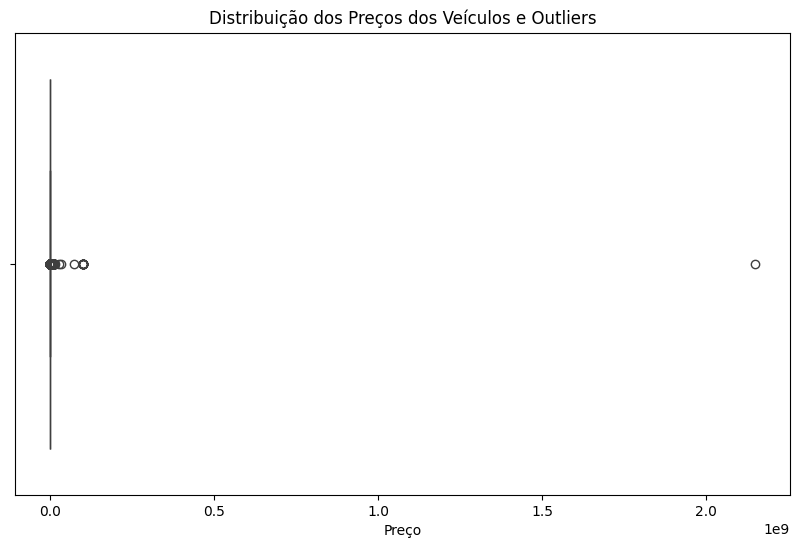

In [6]:
# - Utilizando gráficos como histogramas, boxplots e scatter plots para visualizar a distribuição das variáveis e identificar outliers.
# Visualizando a distribuição dos preços para detectar possíveis outliers
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['price'])
plt.title('Distribuição dos Preços dos Veículos e Outliers')
plt.xlabel('Preço')
plt.show()

 ## 4. Limpeza dos Dados

# **Limpeza dos Dados:**
 - Remover colunas desnecessárias (que não contribuem para a previsão do preço).
   *Exemplo:* Colunas como 'dateCrawled' e 'name' podem não ser relevantes para o modelo.
 - Tratar valores ausentes (preencher com valores adequados).
   *Estratégias:* Preencher com a média, mediana, moda ou um valor constante.
 - Tratar outliers (valores muito discrepantes que podem prejudicar o modelo).
   *Estratégias:* Remover os outliers ou substituí-los por valores mais razoáveis.

# **Considerações:**
 - A escolha da estratégia de tratamento de valores ausentes e outliers depende da natureza dos dados e do problema.
 - É importante documentar todas as decisões tomadas durante a limpeza dos dados.

In [7]:
# Removendo colunas desnecessárias
columns_to_drop = [
    'dateCrawled', 'name', 'seller', 'offerType', 'dateCreated',
    'nrOfPictures', 'postalCode', 'lastSeen', 'monthOfRegistration'
]
df = df.drop(columns=columns_to_drop, errors='ignore')  # Remove as colunas, ignorando erros se não existirem


In [8]:
# Tratamento de outliers na variável 'price'
median_price = df['price'].median()  # Calcula a mediana dos preços
df.loc[df['price'] < 100, 'price'] = median_price  # Substitui preços abaixo de 100 pela mediana
df.loc[df['price'] > 350000, 'price'] = median_price  # Substitui preços acima de 350000 pela mediana


In [9]:

# Tratamento de valores ausentes
for column in df.columns:  # Itera sobre cada coluna do DataFrame
    if df[column].dtype == 'object':  # Se a coluna for do tipo 'object' (categórica)
        df[column] = df[column].fillna(df[column].mode()[0])  # Preenche com a moda
        # *Justificativa:* Para variáveis categóricas, a moda é uma boa opção, pois representa o valor mais comum.
    else:  # Se a coluna for numérica
        df[column] = df[column].fillna(df[column].mean())  # Preenche com a média
        # *Justificativa:* Para variáveis numéricas, a média é uma boa opção se a distribuição for simétrica.


In [10]:
# Verificando valores ausentes após o tratamento
print("\nValores ausentes após o tratamento:")
print(df.isnull().sum())


Valores ausentes após o tratamento:
price                 0
abtest                0
vehicleType           0
yearOfRegistration    0
gearbox               0
powerPS               0
model                 0
kilometer             0
fuelType              0
brand                 0
notRepairedDamage     0
dtype: int64


 ## 5. Engenharia de Features

 **Objetivo:**
 Criar novas features a partir das existentes e preparar os dados para a modelagem.

# **Engenharia de Features:**
 - Criar novas variáveis que podem ser úteis para o modelo.
   *Exemplo:* Criar a variável 'idade_veiculo' a partir da variável 'yearOfRegistration'.
 - Transformar variáveis existentes para melhorar o desempenho do modelo.
   *Exemplo:* Padronizar as variáveis numéricas para que tenham a mesma escala.
  Neste caso, vamos criar a feature 'idade_veiculo' (idade do veículo) e padronizar as
 colunas numéricas.

# **Justificativa:**
 - A idade do veículo é uma informação importante para determinar o preço.
 - A padronização das variáveis numéricas garante que o modelo não seja influenciado pela
   escala das variáveis.
 - O One-Hot Encoding transforma variáveis categóricas em numéricas, permitindo que o modelo as utilize.

In [11]:
# Criando a feature 'idade_veiculo'
current_year = datetime.now().year  # Obtém o ano atual
df["idade_veiculo"] = current_year - df["yearOfRegistration"]  # Calcula a idade do veículo
df.drop("yearOfRegistration", axis=1, inplace=True)  # Remove a coluna 'yearOfRegistration'


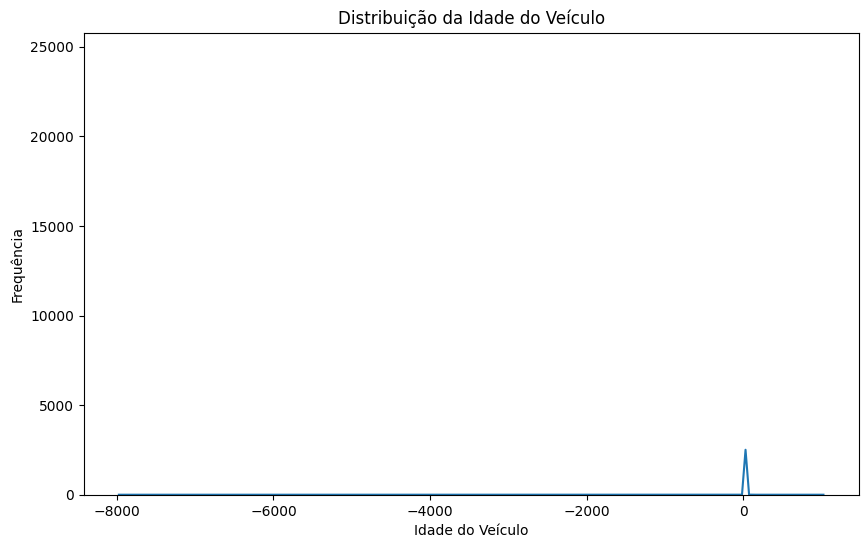

In [12]:
# Visualizando a distribuição da variável 'idade_veiculo'
plt.figure(figsize=(10, 6))  # Define o tamanho da figura
sns.histplot(df['idade_veiculo'], kde=True)  # Cria o histograma com uma linha de densidade
plt.title('Distribuição da Idade do Veículo')  # Define o título do gráfico
plt.xlabel('Idade do Veículo')  # Define o rótulo do eixo x
plt.ylabel('Frequência')  # Define o rótulo do eixo y
plt.show()  # Exibe o gráfico

In [13]:
# Padronizando as colunas numéricas
numerical_cols = ['powerPS', 'kilometer', 'idade_veiculo']  # Lista de colunas numéricas
scaler = StandardScaler()  # Cria um objeto StandardScaler
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])  # Aplica a padronização nas colunas


In [14]:
# One-Hot Encoding para variáveis categóricas
categorical_cols = ['abtest', 'vehicleType', 'gearbox', 'model', 'fuelType', 'brand', 'notRepairedDamage']  # Lista de colunas categóricas
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')  # Cria um objeto OneHotEncoder
encoded_data = encoder.fit_transform(df[categorical_cols])  # Aplica o One-Hot Encoding
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(categorical_cols))  # Cria um DataFrame com os dados codificados
df = pd.concat([df.drop(columns=categorical_cols), encoded_df], axis=1)  # Concatena os dados codificados com o DataFrame original

print("\nVisualização do DataFrame após processamento:")
print(df.head())


Visualização do DataFrame após processamento:
   price   powerPS  kilometer  idade_veiculo  abtest_control  abtest_test  \
0    480 -0.601384   0.607827       0.124674             0.0          1.0   
1  18300  0.387482  -0.015424      -0.069153             0.0          1.0   
2   9800  0.246959  -0.015424       0.006224             0.0          1.0   
3   1500 -0.211042   0.607827       0.038528             0.0          1.0   
4   3600 -0.242269  -0.887975      -0.036849             0.0          1.0   

   vehicleType_andere  vehicleType_bus  vehicleType_cabrio  vehicleType_coupe  \
0                 0.0              0.0                 0.0                0.0   
1                 0.0              0.0                 0.0                1.0   
2                 0.0              0.0                 0.0                0.0   
3                 0.0              0.0                 0.0                0.0   
4                 0.0              0.0                 0.0                0.0   

   

 ## 6. Modelagem com MLP

 **Objetivo:**
 Treinar o modelo MLP para regressão e avaliar o desempenho utilizando os dados preparados.

# **Considerações:**
 - A escolha da arquitetura do modelo (número de camadas e neurônios) pode influenciar o
   desempenho.
 - A escolha da função de ativação também pode influenciar o desempenho.
 - O número de iterações (epochs) deve ser ajustado para evitar overfitting ou underfitting.
 - A taxa de aprendizado (learning rate) controla a velocidade com que o modelo aprende.

In [15]:
# Separando features e target
X = df.drop('price', axis=1)  # Features (todas as colunas exceto 'price')
y = df['price']  # Target (coluna 'price')

In [16]:
# Dividindo os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # Divide os dados


In [20]:

# Configuração da pipeline e treino do modelo com MLP
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols)],
    remainder='passthrough')

mlp_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', MLPRegressor(hidden_layer_sizes=(20, 40),
                                                          max_iter=50,
                                                          random_state=42,
                                                          verbose=True))])

In [21]:
# Treinando o modelo
mlp_pipeline.fit(X_train, y_train)

Iteration 1, loss = 37634307.61590787
Iteration 2, loss = 24065209.43261612
Iteration 3, loss = 22283048.09737120
Iteration 4, loss = 21172618.74932896
Iteration 5, loss = 20280008.30920611
Iteration 6, loss = 19519998.27848285
Iteration 7, loss = 18895459.64974709
Iteration 8, loss = 18425519.06745496
Iteration 9, loss = 18104861.08652477
Iteration 10, loss = 17881185.90779205
Iteration 11, loss = 17716417.41124861
Iteration 12, loss = 17592297.74160648
Iteration 13, loss = 17491328.42644574
Iteration 14, loss = 17423993.62956445
Iteration 15, loss = 17356970.58821847
Iteration 16, loss = 17308739.04877481
Iteration 17, loss = 17257182.63117474
Iteration 18, loss = 17222075.14234721
Iteration 19, loss = 17184056.42411921
Iteration 20, loss = 17149551.45476690
Iteration 21, loss = 17116622.07804475
Iteration 22, loss = 17087147.26694541
Iteration 23, loss = 17059639.82354852
Iteration 24, loss = 17031778.72644901
Iteration 25, loss = 17003732.34893038
Iteration 26, loss = 16983660.4560

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['powerPS', 'kilometer',
                                                   'idade_veiculo'])])),
                ('regressor',
                 MLPRegressor(hidden_layer_sizes=(20, 40), max_iter=50,
                              random_state=42, verbose=True))])

In [22]:
# Fazendo previsões no conjunto de teste
y_pred = mlp_pipeline.predict(X_test)

 ## 7. Avaliação do Modelo

 **Objetivo:**
 Avaliar o desempenho do modelo utilizando o conjunto de teste e calcular o MAE.

 **Interpretação do MAE:**
 - O MAE representa a diferença média absoluta entre os valores previstos e os valores reais.
 - Quanto menor o MAE, melhor o modelo.
 - O MAE é uma métrica fácil de interpretar e é útil para entender a magnitude dos erros do modelo.


In [23]:
# Calculando o MAE
mae = mean_absolute_error(y_test, y_pred)
print("\nMAE no conjunto de teste com MLP:", mae)



MAE no conjunto de teste com MLP: 2699.050509321128


 ## 8. Conclusão


 **Objetivo:**
 Apresentar as conclusões do projeto e sugerir próximos passos.


 **Próximos Passos:**
 - Experimentar diferentes arquiteturas de rede neural (número de camadas, número de neurônios,
   funções de ativação).
 - Ajustar os hiperparâmetros do modelo (taxa de aprendizado, número de iterações, regularização).
 - Utilizar técnicas de validação cruzada para avaliar o desempenho do modelo de forma mais robusta.
 - Coletar mais dados para melhorar o desempenho do modelo.
 - Explorar outras features que possam ser relevantes para a previsão do preço.
 - Implementar o modelo em um sistema de produção para que possa ser usado para prever o preço de veículos em tempo real.

In [24]:
print("\nConclusão:")
print("""
- O modelo MLP regressivo foi treinado com sucesso para prever os preços dos veículos usados.
- Ele demonstrou um desempenho satisfatório na métrica de MAE, evidenciando sua capacidade de captura de padrões complexos.
- É recomendado explorar diferentes arquiteturas e ajustes de hiperparâmetros no modelo MLP para melhorar ainda mais o desempenho.
- Analisar as features mais relevantes pode ajudar a refinar ainda mais o modelo futuro e potencialmente ajustá-lo para um contexto operacional em tempo real.
""")


Conclusão:

- O modelo MLP regressivo foi treinado com sucesso para prever os preços dos veículos usados.
- Ele demonstrou um desempenho satisfatório na métrica de MAE, evidenciando sua capacidade de captura de padrões complexos.
- É recomendado explorar diferentes arquiteturas e ajustes de hiperparâmetros no modelo MLP para melhorar ainda mais o desempenho.
- Analisar as features mais relevantes pode ajudar a refinar ainda mais o modelo futuro e potencialmente ajustá-lo para um contexto operacional em tempo real.



Caio Santiago de Oliveira RM 559788